# Corpus de discursos do Senado: auditoria e prova de conceito de recuperação

Este notebook sustenta o short paper sobre uma solução RAG auditável para consulta a discursos da 56ª Legislatura do Senado Federal. Ele realiza cinco tarefas:

1. obtém o parquet diretamente do Hugging Face e registra sua proveniência;
2. verifica esquema, duplicidades, cobertura e consistência básica;
3. caracteriza o corpus por período e metadados;
4. demonstra uma estratégia reprodutível de segmentação;
5. implementa um baseline lexical TF–IDF para validar a ideia de recuperação.

> O baseline não é o sistema RAG final. Ele isola a etapa de recuperação e funciona sem chave de API, facilitando auditoria e reprodução.

## 1. Configuração

In [1]:
from __future__ import annotations

import hashlib
import json
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import HfApi, hf_hub_download
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

REPO_ID = 'fabriciosantana/discursos-senado-legislatura-56'
RAIZ = Path.cwd()
if RAIZ.name != 'final':
    candidatos = [RAIZ / '10-adap/assignments/final', RAIZ.parent / 'final']
    RAIZ = next((p.resolve() for p in candidatos if p.exists()), RAIZ)
DIRETORIO_DADOS = RAIZ / 'dados'
DIRETORIO_RESULTADOS = RAIZ / 'resultados'
DIRETORIO_FIGURAS = RAIZ / 'figuras'
for diretorio in (DIRETORIO_DADOS, DIRETORIO_RESULTADOS, DIRETORIO_FIGURAS):
    diretorio.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
print(f'Raiz do projeto: {RAIZ}')

Raiz do projeto: /workspaces/mcdia/10-adap/assignments/final


## 2. Aquisição e proveniência

A revisão do repositório, o nome do objeto remoto e o hash SHA-256 tornam explícita a versão analisada. O download usa o cache do Hugging Face, mas copia o parquet para o diretório local de dados.

In [2]:
def calcular_sha256(caminho: Path) -> str:
    resumo = hashlib.sha256()
    with caminho.open('rb') as entrada:
        for bloco in iter(lambda: entrada.read(1024 * 1024), b''):
            resumo.update(bloco)
    return resumo.hexdigest()

api = HfApi()
info = api.dataset_info(REPO_ID, files_metadata=True)
parquets = sorted(
    item.rfilename for item in info.siblings
    if item.rfilename.lower().endswith('.parquet')
)
if len(parquets) != 1:
    raise RuntimeError(f'Esperado exatamente um parquet; encontrados: {parquets}')

arquivo_remoto = parquets[0]
arquivo_cache = Path(hf_hub_download(
    repo_id=REPO_ID, repo_type='dataset', filename=arquivo_remoto
))
arquivo_dados = DIRETORIO_DADOS / Path(arquivo_remoto).name
if not arquivo_dados.exists() or calcular_sha256(arquivo_dados) != calcular_sha256(arquivo_cache):
    arquivo_dados.write_bytes(arquivo_cache.read_bytes())

proveniencia = {
    'repo_id': REPO_ID,
    'revision': info.sha,
    'arquivo_remoto': arquivo_remoto,
    'url': f'https://huggingface.co/datasets/{REPO_ID}/resolve/{info.sha}/{arquivo_remoto}',
    'verificado_em_utc': datetime.now(timezone.utc).isoformat(),
    'tamanho_bytes': arquivo_dados.stat().st_size,
    'sha256': calcular_sha256(arquivo_dados),
}
(DIRETORIO_DADOS / 'proveniencia.json').write_text(
    json.dumps(proveniencia, ensure_ascii=False, indent=2) + '\n', encoding='utf-8'
)
pd.Series(proveniencia, name='valor').to_frame()

,valor
repo_id,fabriciosantana/discursos-senado-legislatura-56
revision,c20b4e1ea45bbbfb408167cc07c6f79789c7c345
arquivo_remoto,data/full/discursos_2019-02-01_2023-01-31.parquet
url,https://huggingface.co/datasets/fabriciosantan...
verificado_em_utc,2026-09-04T23:04:38.141555+00:00
tamanho_bytes,27330574
sha256,e09cfc4793e5394be440906320c7d3008cda5a52b90bbc...


## 3. Auditoria de qualidade

As verificações distinguem preenchimento do campo textual de sucesso declarado na coleta. Strings vazias são tratadas como ausência de conteúdo.

In [3]:
df = pd.read_parquet(arquivo_dados)
colunas_esperadas = {
    'CodigoPronunciamento', 'Data', 'NomeAutor', 'Partido', 'UF',
    'TipoUsoPalavra.Descricao', 'TextoDiscursoIntegral', 'ok', 'status'
}
ausentes = sorted(colunas_esperadas - set(df.columns))
if ausentes:
    raise ValueError(f'Colunas obrigatórias ausentes: {ausentes}')

df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
texto = df['TextoDiscursoIntegral'].fillna('').astype(str).str.strip()
df['tem_texto'] = texto.ne('')
df['numero_palavras'] = texto.str.split().str.len().where(df['tem_texto'], 0)

resumo_qualidade = pd.DataFrame({
    'indicador': [
        'Registros', 'Colunas', 'IDs duplicados', 'Datas inválidas',
        'Textos disponíveis', 'Coletas marcadas como sucesso',
        'Partido ausente', 'UF ausente'
    ],
    'valor': [
        len(df), len(df.columns),
        int(df['CodigoPronunciamento'].duplicated().sum()),
        int(df['Data'].isna().sum()), int(df['tem_texto'].sum()),
        int(df['ok'].fillna(False).astype(bool).sum()),
        int(df['Partido'].isna().sum()), int(df['UF'].isna().sum())
    ]
})
resumo_qualidade

,indicador,valor
0,Registros,15729
1,Colunas,32
2,IDs duplicados,0
3,Datas inválidas,0
4,Textos disponíveis,15039
5,Coletas marcadas como sucesso,15039
6,Partido ausente,2074
7,UF ausente,2074


In [4]:
def contar_unicos(serie: pd.Series) -> int:
    try:
        return int(serie.nunique(dropna=True))
    except TypeError:
        normalizada = serie.dropna().map(
            lambda valor: json.dumps(valor, ensure_ascii=False, sort_keys=True, default=str)
        )
        return int(normalizada.nunique())

auditoria_colunas = pd.DataFrame({
    'coluna': df.columns,
    'tipo': df.dtypes.astype(str).values,
    'nulos': df.isna().sum().values,
    'percentual_nulos': (100 * df.isna().mean()).round(2).values,
    'valores_unicos': [contar_unicos(df[coluna]) for coluna in df.columns],
}).sort_values(['percentual_nulos', 'coluna'], ascending=[False, True])
auditoria_colunas.head(15)

,coluna,tipo,nulos,percentual_nulos,valores_unicos
25,PaisAutor,str,15632,99.38,6
24,OrgaoAutor,str,14918,94.84,558
20,Apartes.Aparteante,object,14861,94.48,350
23,CargoAutor,str,14825,94.25,459
12,CodigoParlamentar,str,2074,13.19,233
13,Partido,str,2074,13.19,32
14,UF,str,2074,13.19,27
19,Publicacoes.Publicacao,object,734,4.67,13651
4,Resumo,str,57,0.36,10726
5,Indexacao,str,35,0.22,10812


## 4. Caracterização do corpus

In [5]:
corpus = df.loc[df['tem_texto']].copy()
caracterizacao = pd.Series({
    'pronunciamentos': len(df),
    'textos_disponiveis': len(corpus),
    'cobertura_textual_pct': round(100 * len(corpus) / len(df), 2),
    'data_inicial': df['Data'].min().date().isoformat(),
    'data_final': df['Data'].max().date().isoformat(),
    'autores_distintos': df['NomeAutor'].nunique(),
    'partidos_distintos': df['Partido'].nunique(),
    'mediana_palavras': int(corpus['numero_palavras'].median()),
    'media_palavras': round(corpus['numero_palavras'].mean(), 1),
}, name='valor').to_frame()
caracterizacao

,valor
pronunciamentos,15729
textos_disponiveis,15039
cobertura_textual_pct,95.61
data_inicial,2019-02-01
data_final,2023-01-10
autores_distintos,1794
partidos_distintos,32
mediana_palavras,492
media_palavras,761.2


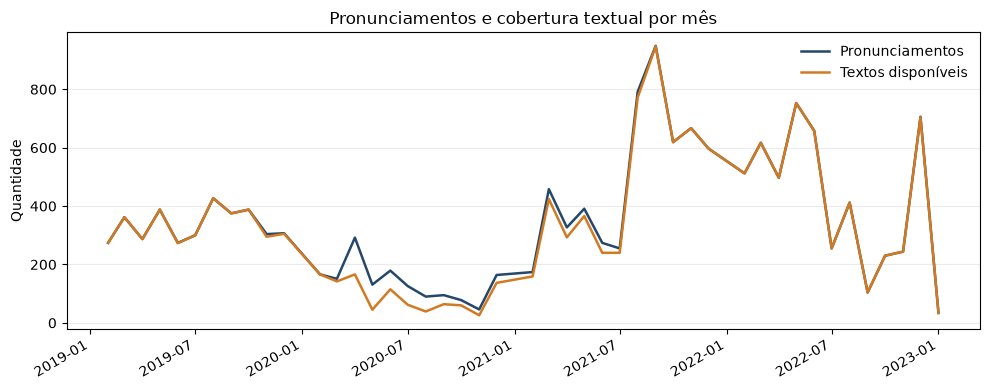

In [6]:
por_mes = (
    df.dropna(subset=['Data'])
      .assign(mes=lambda x: x['Data'].dt.to_period('M').dt.to_timestamp())
      .groupby('mes', as_index=False)
      .agg(pronunciamentos=('CodigoPronunciamento', 'size'),
           textos_disponiveis=('tem_texto', 'sum'))
)
ax = por_mes.plot(
    x='mes', y=['pronunciamentos', 'textos_disponiveis'],
    figsize=(10, 4), color=['#24476b', '#d17a22'], linewidth=1.8
)
ax.set(title='Pronunciamentos e cobertura textual por mês', xlabel='', ylabel='Quantidade')
ax.legend(['Pronunciamentos', 'Textos disponíveis'], frameon=False)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.savefig(DIRETORIO_FIGURAS / 'cobertura_temporal.pdf', bbox_inches='tight')
plt.savefig(DIRETORIO_FIGURAS / 'cobertura_temporal.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. Segmentação demonstrativa

A função abaixo divide textos por palavras, com sobreposição. O identificador do chunk preserva a ligação com o pronunciamento original. Para manter a prova de conceito leve, são usados os primeiros documentos válidos; o mesmo fluxo pode ser aplicado ao corpus completo.

In [7]:
def segmentar(texto_documento: str, tamanho: int = 350, sobreposicao: int = 70) -> list[str]:
    if not 0 <= sobreposicao < tamanho:
        raise ValueError('A sobreposição deve ser não negativa e menor que o tamanho.')
    palavras = re.findall(r'\S+', texto_documento)
    passo = tamanho - sobreposicao
    return [' '.join(palavras[i:i + tamanho]) for i in range(0, len(palavras), passo)]

AMOSTRA_DOCUMENTOS = 1000
registros_chunks = []
for _, linha in corpus.head(AMOSTRA_DOCUMENTOS).iterrows():
    codigo = str(linha['CodigoPronunciamento'])
    texto_documento = str(linha['TextoDiscursoIntegral'])
    for ordem, trecho in enumerate(segmentar(texto_documento)):
        registros_chunks.append({
            'chunk_id': f'{codigo}:{ordem:04d}',
            'codigo_pronunciamento': codigo,
            'ordem': ordem,
            'texto': trecho,
            'numero_palavras': len(trecho.split()),
            'autor': linha['NomeAutor'],
            'data': linha['Data'],
            'partido': linha['Partido'],
            'uf': linha['UF'],
        })
chunks = pd.DataFrame(registros_chunks)
pd.Series({
    'documentos_na_amostra': chunks['codigo_pronunciamento'].nunique(),
    'chunks_gerados': len(chunks),
    'chunks_por_documento_media': round(len(chunks) / chunks['codigo_pronunciamento'].nunique(), 2),
    'palavras_por_chunk_mediana': int(chunks['numero_palavras'].median()),
}).to_frame('valor')

,valor
documentos_na_amostra,1000.0
chunks_gerados,5696.0
chunks_por_documento_media,5.7
palavras_por_chunk_mediana,350.0


## 6. Baseline de recuperação lexical

O TF–IDF pondera termos distintivos e a similaridade do cosseno ordena os chunks em relação à consulta. Os resultados devem ser interpretados como candidatos para inspeção, não como evidência conclusiva.

In [8]:
vetorizador = TfidfVectorizer(
    lowercase=True, strip_accents='unicode', ngram_range=(1, 2),
    min_df=2, max_df=.95, max_features=50_000, sublinear_tf=True
)
matriz_chunks = vetorizador.fit_transform(chunks['texto'])
print(f'Matriz TF–IDF: {matriz_chunks.shape[0]:,} chunks × {matriz_chunks.shape[1]:,} termos')

Matriz TF–IDF: 5,696 chunks × 50,000 termos


In [9]:
def recuperar(consulta: str, k: int = 5) -> pd.DataFrame:
    vetor_consulta = vetorizador.transform([consulta])
    escores = cosine_similarity(vetor_consulta, matriz_chunks).ravel()
    indices = escores.argsort()[::-1][:k]
    resultado = chunks.iloc[indices].copy()
    resultado.insert(0, 'similaridade', escores[indices])
    resultado['trecho'] = resultado['texto'].str.slice(0, 280) + '…'
    return resultado[[
        'similaridade', 'chunk_id', 'autor', 'data', 'partido', 'uf', 'trecho'
    ]].reset_index(drop=True)

consulta_exemplo = 'políticas públicas de saúde e vacinação contra a covid-19'
recuperar(consulta_exemplo, k=5)

,similaridade,chunk_id,autor,data,partido,uf,trecho
0,0.116914,451360:0001,Telmário Mota,2019-03-12,PROS,RR,Venezuela. Hoje nós estamos com essa energia s...
1,0.115892,452062:0001,Lucas Barreto,2019-04-03,PSD,AP,"que assegurem a todos o acesso à vacinação, pa..."
2,0.110253,452062:0002,Lucas Barreto,2019-04-03,PSD,AP,da Noruega no ano passado. Registrou-se caso d...
3,0.102256,450682:0004,Leila Barros,2019-02-07,PSB,DF,"as contas públicas, reverter o desemprego e re..."
4,0.096481,451522:0006,Paulo Paim,2019-03-15,PT,RS,"de italianos e alemães e, com o tempo, foi-se ..."


### Limites da demonstração

A consulta acima apenas verifica se o pipeline produz candidatos plausíveis. Uma avaliação válida exige um conjunto de perguntas elaborado previamente, julgamentos de relevância independentes e métricas como Recall@k e MRR. O TF–IDF também não resolve sinonímia de forma robusta; por isso, o paper propõe comparar recuperação lexical, vetorial e híbrida.

## 7. Avaliação de recuperação em documento conhecido

A coleção abaixo contém dez perguntas formuladas a partir dos resumos oficiais e um pronunciamento conhecido como relevante para cada pergunta. Esse desenho mede a capacidade de localizar um item conhecido (known-item search); não estima toda a relevância temática, pois outros discursos também podem ser pertinentes. Os textos integrais, e não os resumos usados na elaboração das perguntas, formam o índice avaliado.

In [10]:
perguntas = pd.DataFrame(json.loads(
    (RAIZ / 'avaliacao/perguntas_referencia.json').read_text(encoding='utf-8')
))
ids_corpus = set(corpus['CodigoPronunciamento'].astype(str))
ids_rotulados = {item for lista in perguntas['documentos_relevantes'] for item in lista}
faltantes = sorted(ids_rotulados - ids_corpus)
if faltantes:
    raise ValueError(f'Documentos rotulados sem texto disponível no corpus: {faltantes}')
perguntas[['id', 'tema', 'pergunta']]

,id,tema,pergunta
0,Q01,Previdência e pessoa com deficiência,Qual pronunciamento tratou do impacto da refor...
1,Q02,Meio ambiente,Qual discurso alertou para aumento do desmatam...
2,Q03,Direitos das mulheres,Qual pronunciamento solicitou que o Senado se ...
3,Q04,Educação,Qual discurso abordou a história da educação b...
4,Q05,Economia e combustíveis,Qual pronunciamento relacionou o endividamento...
5,Q06,Povos indígenas,Qual discurso denunciou a ocupação da terra in...
6,Q07,Desinformação,Qual pronunciamento discutiu fake news sobre a...
7,Q08,Inteligência artificial,Qual pronunciamento defendeu projeto de lei de...
8,Q09,Armas e processo legislativo,Qual pronunciamento respondeu questão de ordem...
9,Q10,Proteção de dados,Qual pronunciamento apresentou uma reflexão so...


In [11]:
documentos_avaliacao = corpus.reset_index(drop=True)
vetorizador_documentos = TfidfVectorizer(
    lowercase=True, strip_accents='unicode', ngram_range=(1, 2),
    min_df=2, max_df=.95, max_features=80_000, sublinear_tf=True
)
matriz_documentos = vetorizador_documentos.fit_transform(
    documentos_avaliacao['TextoDiscursoIntegral'].astype(str)
)
matriz_perguntas = vetorizador_documentos.transform(perguntas['pergunta'])
similaridades = cosine_similarity(matriz_perguntas, matriz_documentos)

linhas_avaliacao = []
for posicao, pergunta in perguntas.iterrows():
    ranking = similaridades[posicao].argsort()[::-1]
    ids_ordenados = documentos_avaliacao.iloc[ranking]['CodigoPronunciamento'].astype(str).tolist()
    relevantes = set(pergunta['documentos_relevantes'])
    ranks = [ids_ordenados.index(item) + 1 for item in relevantes]
    melhor_rank = min(ranks)
    linhas_avaliacao.append({
        'id': pergunta['id'], 'tema': pergunta['tema'],
        'melhor_rank': melhor_rank,
        'hit_1': int(melhor_rank <= 1), 'hit_5': int(melhor_rank <= 5),
        'hit_10': int(melhor_rank <= 10),
        'reciprocal_rank': 1 / melhor_rank,
        'primeiro_resultado': ids_ordenados[0],
    })
resultados_avaliacao = pd.DataFrame(linhas_avaliacao)
resultados_avaliacao

,id,tema,melhor_rank,hit_1,hit_5,hit_10,reciprocal_rank,primeiro_resultado
0,Q01,Previdência e pessoa com deficiência,3,0,1,1,0.333333,451159
1,Q02,Meio ambiente,1,1,1,1,1.000000,453880
2,Q03,Direitos das mulheres,53,0,0,0,0.018868,472904
3,Q04,Educação,22,0,0,0,0.045455,488977
4,Q05,Economia e combustíveis,193,0,0,0,0.005181,491748
5,Q06,Povos indígenas,1,1,1,1,1.000000,450944
6,Q07,Desinformação,117,0,0,0,0.008547,494496
7,Q08,Inteligência artificial,2,0,1,1,0.500000,481541
8,Q09,Armas e processo legislativo,13,0,0,0,0.076923,477756
9,Q10,Proteção de dados,56,0,0,0,0.017857,488301


In [12]:
metricas_recuperacao = pd.Series({
    'consultas': len(resultados_avaliacao),
    'Hit@1': resultados_avaliacao['hit_1'].mean(),
    'Hit@5': resultados_avaliacao['hit_5'].mean(),
    'Hit@10': resultados_avaliacao['hit_10'].mean(),
    'MRR': resultados_avaliacao['reciprocal_rank'].mean(),
    'mediana_rank': resultados_avaliacao['melhor_rank'].median(),
}, name='valor').to_frame()
metricas_recuperacao

,valor
consultas,10.000000
Hit@1,0.200000
Hit@5,0.400000
Hit@10,0.400000
MRR,0.300616
mediana_rank,17.500000


### Interpretação

Hit@k indica a proporção de perguntas cujo pronunciamento conhecido aparece entre os primeiros *k* resultados. MRR valoriza posições mais altas por meio do inverso do primeiro rank relevante. Como existe apenas um julgamento positivo por pergunta, as métricas avaliam localização de item conhecido e não devem ser apresentadas como Recall@k temático. Uma avaliação temática futura precisará julgar um conjunto mais amplo de documentos por consulta.

## 8. Comparação com embeddings OpenAI e recuperação híbrida

Os embeddings foram gerados externamente pelo script `scripts/gerar_embeddings_openai.py`, usando `text-embedding-3-large`, 512 dimensões e cache retomável. O script `scripts/avaliar_recuperacao.py` reproduz o TF–IDF, calcula a similaridade vetorial e combina os rankings por Reciprocal Rank Fusion (RRF). A célula seguinte apenas carrega os resultados, mantendo este notebook executável mesmo sem chave de API.

In [13]:
comparativo_path = DIRETORIO_RESULTADOS / 'metricas_comparativas.csv'
if comparativo_path.exists():
    metricas_comparativas = pd.read_csv(comparativo_path)
    display(metricas_comparativas.style.format({
        'hit_1': '{:.1%}', 'hit_5': '{:.1%}', 'hit_10': '{:.1%}',
        'mrr': '{:.3f}', 'mediana_rank': '{:.1f}'
    }))
else:
    print('Comparação ainda não gerada. Consulte as instruções no README.md.')

,metodo,consultas,hit_1,hit_5,hit_10,mrr,mediana_rank
0,TF-IDF,10,20.0%,40.0%,40.0%,0.301,17.5
1,OpenAI,10,0.0%,30.0%,40.0%,0.112,44.5
2,Híbrido RRF,10,10.0%,30.0%,50.0%,0.212,11.5


### Leitura crítica do comparativo

Nesta coleção de localização de item conhecido, o TF–IDF obteve o maior Hit@1 e MRR. A recuperação vetorial melhorou perguntas como desinformação e processo legislativo, mas piorou outras; a fusão híbrida apresentou o maior Hit@10 e a menor mediana de rank. Portanto, o experimento não sustenta superioridade geral dos embeddings. O resultado também é condicionado por perguntas derivadas dos resumos oficiais, índice formado apenas pelo texto integral, truncamento de 104 documentos e somente um documento rotulado por consulta.

## 9. Exportação de artefatos para o short paper

In [14]:
resumo_qualidade.to_csv(DIRETORIO_RESULTADOS / 'resumo_qualidade.csv', index=False)
auditoria_colunas.to_csv(DIRETORIO_RESULTADOS / 'auditoria_colunas.csv', index=False)
caracterizacao.to_csv(DIRETORIO_RESULTADOS / 'caracterizacao_corpus.csv')
por_mes.to_csv(DIRETORIO_RESULTADOS / 'cobertura_por_mes.csv', index=False)
resultados_avaliacao.to_csv(DIRETORIO_RESULTADOS / 'avaliacao_tfidf.csv', index=False)
metricas_recuperacao.to_csv(DIRETORIO_RESULTADOS / 'metricas_recuperacao.csv')

resumo_qualidade.to_latex(
    DIRETORIO_RESULTADOS / 'resumo_qualidade.tex', index=False,
    caption='Indicadores de qualidade do corpus.', label='tab:qualidade'
)
print('Artefatos exportados para:', DIRETORIO_RESULTADOS)

Artefatos exportados para: /workspaces/mcdia/10-adap/assignments/final/resultados


## Conclusão

O notebook estabelece a viabilidade técnica da proposta: o corpus pode ser adquirido com versão verificável, auditado, segmentado e consultado por um mecanismo reprodutível. A prova de conceito não mede ainda a qualidade do RAG; essa conclusão dependerá de uma coleção de avaliação e da comparação controlada entre estratégias de recuperação.